<a href="https://colab.research.google.com/github/yousefghawi/Cardiovascular-disease-capstone-project/blob/EDA-and-Visualization/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Overview and Cleaning
in this section will:
- load and preview the dataset
- clean the dataset:
   *Missing value
   *Duplicate records
   *Incorrect or inconsistent formats
   *Outliers or unrealistic values
   *Typograghical errors

In [119]:
import pandas as pd
import numpy as np
import missingno as msno

#Column Descriptions


In [120]:
df = pd.read_csv('cardio_train.csv' , sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0.0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1.0
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1.0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1.0
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49956,71303,18893,2,170,85.0,130,80,1,1,0,0,1,1.0
49957,71304,21323,1,158,78.0,140,90,1,1,0,0,1,0.0
49958,71308,16127,2,168,72.0,120,80,1,2,1,0,1,0.0
49959,71309,17579,1,163,45.0,120,80,1,1,0,0,1,0.0




age : in days.
gender : 1 for women, 2 for men.
height : in cm.
weight : in kg.
ap_hi : Systolic blood pressure.
ap_lo : Diastolic blood pressure.
cholesterol : 1=normal, 2=above normal, 3=well above normal.
gluc : glucose (blood sugar level) 1= normal, 2=above normal, 3=well above normal.
smoke : weather patient smokes or not 0=No , 1=Yes

#What the Data Tells Us


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49961 entries, 0 to 49960
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           49961 non-null  int64  
 1   age          49961 non-null  int64  
 2   gender       49961 non-null  int64  
 3   height       49961 non-null  int64  
 4   weight       49961 non-null  float64
 5   ap_hi        49961 non-null  int64  
 6   ap_lo        49961 non-null  int64  
 7   cholesterol  49961 non-null  int64  
 8   gluc         49961 non-null  int64  
 9   smoke        49961 non-null  int64  
 10  alco         49961 non-null  int64  
 11  active       49961 non-null  int64  
 12  cardio       49960 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 5.0 MB


In [122]:
print("Shape:", df.shape)
df.describe().T

Shape: (49961, 13)


,count,mean,std,min,25%,50%,75%,max
id,49961.0,35676.161566,20609.537461,0.0,17836.0,35682.0,53508.0,71310.0
age,49961.0,19464.684094,2469.041025,10798.0,17662.0,19703.0,21321.0,23690.0
gender,49961.0,1.346971,0.476011,1.0,1.0,1.0,2.0,2.0
height,49961.0,164.366166,8.190134,55.0,159.0,165.0,170.0,250.0
weight,49961.0,74.230610,14.327859,11.0,65.0,72.0,82.0,200.0
ap_hi,49961.0,128.747183,154.515534,-150.0,120.0,120.0,140.0,16020.0
ap_lo,49961.0,96.972118,200.225599,0.0,80.0,80.0,90.0,11000.0
cholesterol,49961.0,1.363504,0.677197,1.0,1.0,1.0,1.0,3.0
gluc,49961.0,1.225856,0.572023,1.0,1.0,1.0,1.0,3.0
smoke,49961.0,0.088209,0.283601,0.0,0.0,0.0,0.0,1.0


**Age**
-Stored in days, so dividing by 365: patients range from roughly 30 to 65 years old
-Average age is around 53 years

**Gender**
-Mean of 1.35 means the dataset is mostly female (since 1 = Female)

**Height & Weight**
-Average height: 164 cm, average weight: 74 kg
-Min height of 55 cm and max weight of 200 kg suggest there are outliers worth investigating

**Blood Pressure (ap_hi / ap_lo) — Red Flag**

*ap_hi has a minimum of -150 and a maximum of 16,020 — these are physically impossible values

*ap_lo also has -70 and 11,000 as min/max

*This means the data has serious outliers or data entry errors that must be cleaned before analysis

**Cholesterol & Glucose**
-Most patients have normal levels (median = 1 for both)

**Lifestyle columns (smoke, alco, active)**
Only ~8.8% of patients smoke,
Only ~5.4% drink alcohol,
~80% are physically active.

**Target Variable (cardio)**
-Mean of ~0.50 means the dataset is perfectly balanced — 50% have cardiovascular disease, 50% don't

#Missing Values


In [123]:
df.isna().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


The dataset contains no missing values across all 70,000 records. Every column is fully populated, giving us a complete and reliable foundation for analysis.

#visualise the missing value

<Axes: >

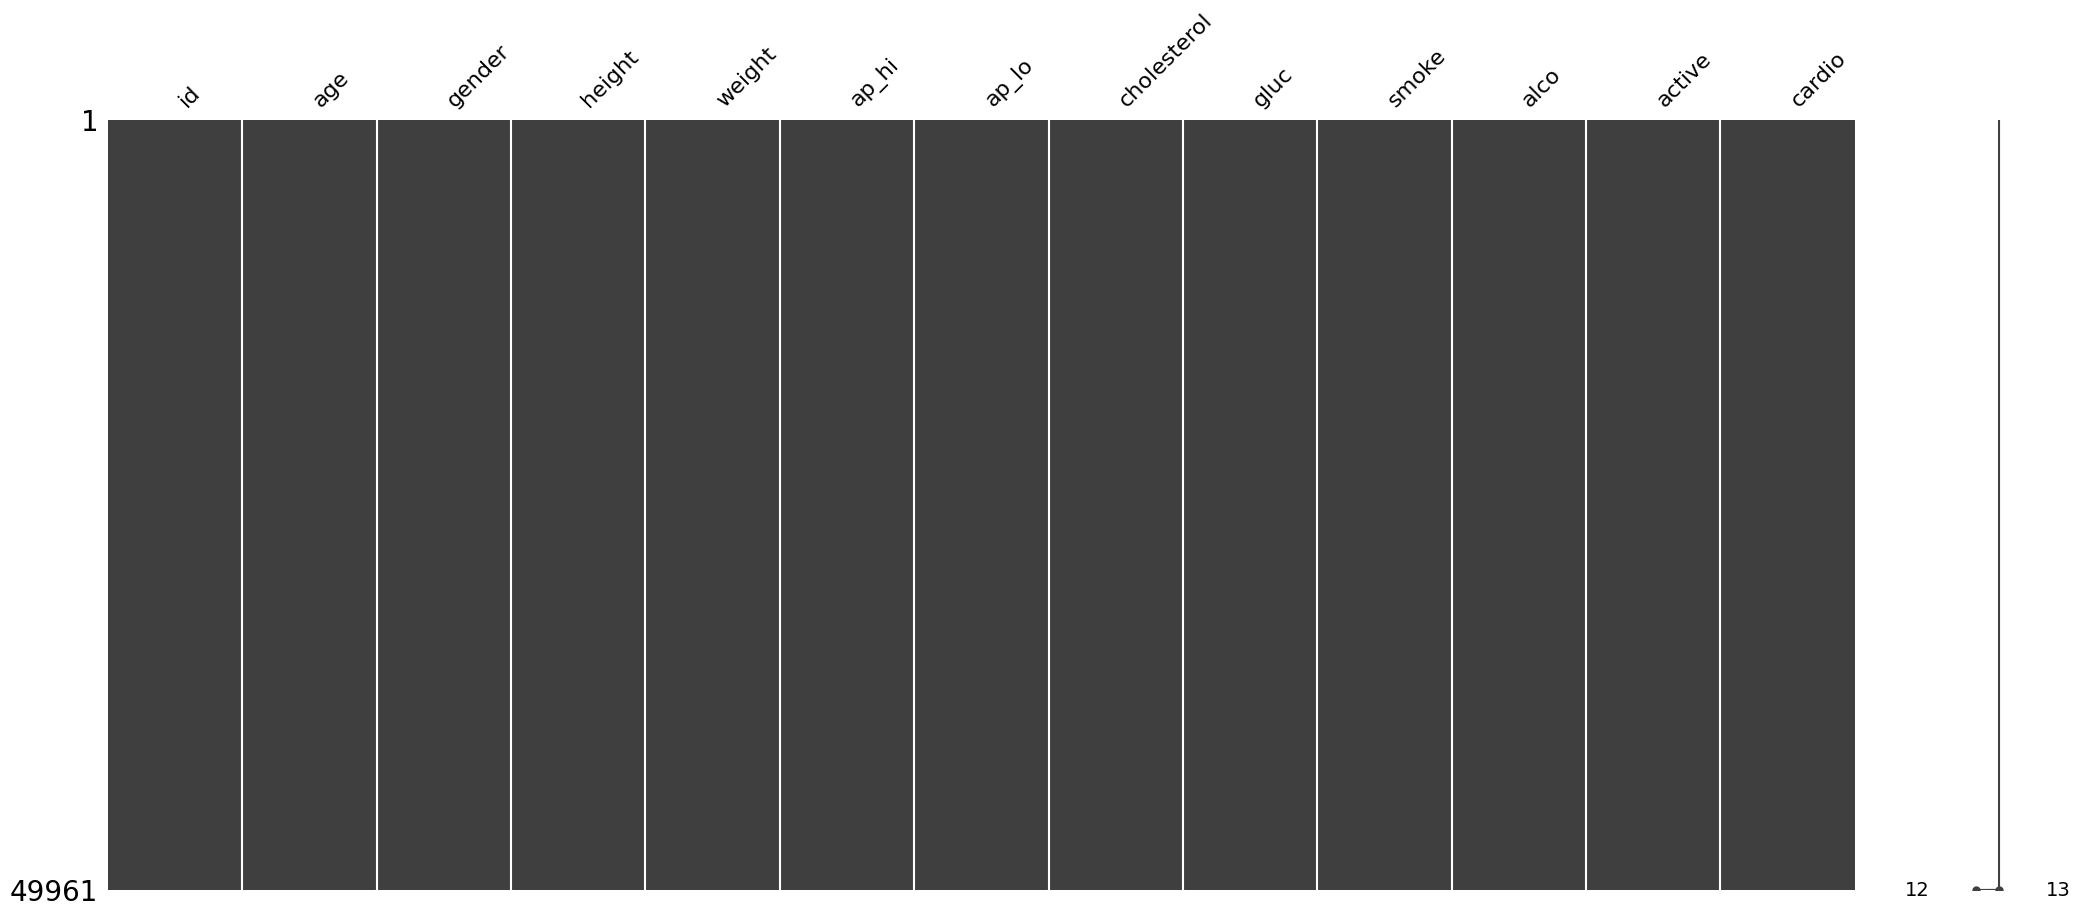

In [124]:
msno.matrix(df)

#Duplicated values

In [125]:
df[df.duplicated()]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


There seems to be no duplicate rows in the data, which is a great sign

#Age Conversion

The age column was originally stored in days and was converted to years by dividing by 365.25 to account for leap years, then cast to integer format for readability.

In [126]:
df['age'] = (df['age'] / 365.25).astype(int)

#Outlier Detection and Removal
Outliers were identified and removed using two approaches

**Blood Pressure (ap_hi, ap_lo):** Medical domain knowledge was applied to filter out physiologically impossible values. Systolic pressure (ap_hi) was restricted to the range 60–250 mmHg, and diastolic pressure (ap_lo) to 40–150 mmHg. Additionally, rows where diastolic pressure exceeded systolic pressure were removed as they are medically invalid.

In [127]:
df = df[df['ap_hi'].between(60, 250)]
df = df[df['ap_lo'].between(40, 150)]


df = df[df['ap_hi'] > df['ap_lo']]

**Height and Weight:** The Interquartile Range (IQR) method was applied. For each column, the lower and upper bounds were calculated as (Q1-1.5×IQR) and (Q3 + 1.5×IQR) respectively. Any value falling outside these bounds was considered an outlier and removed. This approach ensures the cleaning is driven by the actual data distribution rather than manual assumptions.

In [128]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]


for col in ['height', 'weight']:
    df = remove_outliers_iqr(df, col)

**Outcome:** After cleaning, the dataset retains only valid and realistic records, ensuring higher quality and more reliable results in subsequent analysis and modeling.

In [129]:
df.reset_index(drop=True, inplace=True)  #To ensure our id will not have gaps

In [130]:
print("Final shape after outlier removal:", df.shape)
df.describe().T

Final shape after outlier removal: (47457, 13)


,count,mean,std,min,25%,50%,75%,max
id,47457.0,35666.878058,20614.888840,0.0,17804.0,35638.0,53518.0,71310.0
age,47457.0,52.775987,6.773385,29.0,48.0,53.0,58.0,64.0
gender,47457.0,1.343237,0.474795,1.0,1.0,1.0,2.0,2.0
height,47457.0,164.325073,7.539702,143.0,159.0,165.0,170.0,186.0
weight,47457.0,73.038442,12.344925,40.0,65.0,71.0,81.0,107.0
ap_hi,47457.0,126.380176,16.529916,60.0,120.0,120.0,140.0,240.0
ap_lo,47457.0,81.169353,9.341166,40.0,80.0,80.0,90.0,150.0
cholesterol,47457.0,1.355185,0.670755,1.0,1.0,1.0,1.0,3.0
gluc,47457.0,1.220579,0.566747,1.0,1.0,1.0,1.0,3.0
smoke,47457.0,0.086858,0.281629,0.0,0.0,0.0,0.0,1.0


#Feature Engineering

 **Pulse Pressure:** Pulse pressure is the difference between systolic and diastolic blood pressure.We added because it is a well-known medical indicator of cardiovascular risk. A high pulse pressure (above 60 mmHg) indicates that the heart is working harder than normal, which is directly linked to heart disease, arterial stiffness, and stroke. Instead of letting the model figure out this relationship on its own, we calculated it explicitly to give the model a direct and meaningful signal.

In [131]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

**BMI:** BMI (Body Mass Index) was added because it combines both height and weight into a single meaningful metric that reflects a person's body composition. Obesity and being overweight are among the top risk factors for cardiovascular disease. Using BMI instead of raw height and weight separately gives the model a more medically relevant feature, as the relationship between weight and health risk depends heavily on a person's height.

In [132]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

In [133]:
# Realistic BMI range for adults
# Clean the outlier from BMI
df = df[df['bmi'].between(10, 60)]

In [134]:
df.reset_index(drop=True, inplace=True)  #To ensure our id will not have gaps

**BMI Category:** While the numerical BMI value is useful, categorizing it adds an extra layer of interpretability. Medical research classifies BMI into standard risk groups, so by adding this categorical column we help the model recognize established medical thresholds rather than treating all BMI values as a continuous scale with no meaningful breakpoints.

In [135]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

**To check our changes in the dataset**

In [136]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,pulse_pressure,bmi,bmi_category
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0.0,30,21.967120,Normal
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1.0,50,34.927679,Obese
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1.0,60,23.507805,Normal
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1.0,50,28.710479,Overweight
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0.0,40,23.011177,Normal


# Exploratory Data Analysis (EDA) & Visualization

In [137]:
df.shape
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47457 entries, 0 to 47456
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              47457 non-null  int64  
 1   age             47457 non-null  int64  
 2   gender          47457 non-null  int64  
 3   height          47457 non-null  int64  
 4   weight          47457 non-null  float64
 5   ap_hi           47457 non-null  int64  
 6   ap_lo           47457 non-null  int64  
 7   cholesterol     47457 non-null  int64  
 8   gluc            47457 non-null  int64  
 9   smoke           47457 non-null  int64  
 10  alco            47457 non-null  int64  
 11  active          47457 non-null  int64  
 12  cardio          47456 non-null  float64
 13  pulse_pressure  47457 non-null  int64  
 14  bmi             47457 non-null  float64
 15  bmi_category    47457 non-null  object 
dtypes: float64(3), int64(12), object(1)
memory usage: 5.8+ MB


,count,mean,std,min,25%,50%,75%,max
id,47457.0,35666.878058,20614.888840,0.000000,17804.000000,35638.000000,53518.000000,71310.000000
age,47457.0,52.775987,6.773385,29.000000,48.000000,53.000000,58.000000,64.000000
gender,47457.0,1.343237,0.474795,1.000000,1.000000,1.000000,2.000000,2.000000
height,47457.0,164.325073,7.539702,143.000000,159.000000,165.000000,170.000000,186.000000
weight,47457.0,73.038442,12.344925,40.000000,65.000000,71.000000,81.000000,107.000000
ap_hi,47457.0,126.380176,16.529916,60.000000,120.000000,120.000000,140.000000,240.000000
ap_lo,47457.0,81.169353,9.341166,40.000000,80.000000,80.000000,90.000000,150.000000
cholesterol,47457.0,1.355185,0.670755,1.000000,1.000000,1.000000,1.000000,3.000000
gluc,47457.0,1.220579,0.566747,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,47457.0,0.086858,0.281629,0.000000,0.000000,0.000000,0.000000,1.000000


## BMI Category Analysis

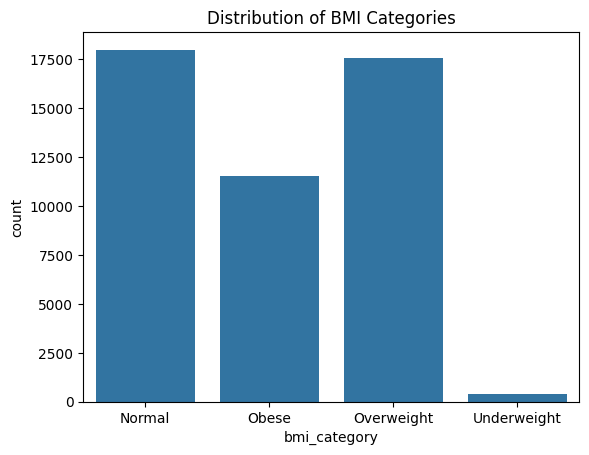

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='bmi_category', data=df)
plt.title("Distribution of BMI Categories")
plt.show()

 Imbalance
There is a clear imbalance:
- Underweight is very low  
- Most data is concentrated in Normal and Overweight  

 Most Common Categories
- Normal (highest)  
- Overweight (close second)  
- Obese  
- Underweight (lowest)  

 Key Insight
Most individuals are Normal or Overweight.  
Further analysis with `cardio` is needed to check if Normal weight reduces disease risk.

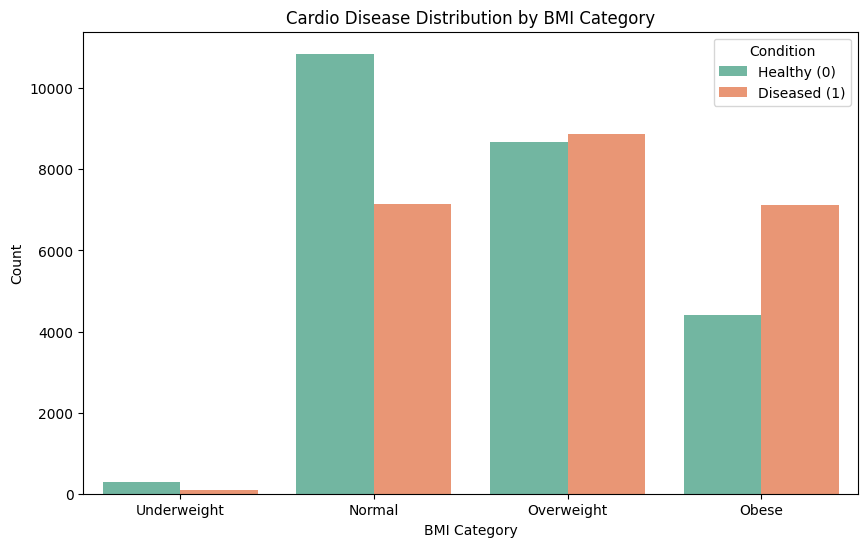

In [139]:
plt.figure(figsize=(10,6))
sns.countplot(
    x='bmi_category',
    hue='cardio',
    data=df,
    order=['Underweight', 'Normal', 'Overweight', 'Obese'],
    palette='Set2'
)

plt.title("Cardio Disease Distribution by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.legend(title='Condition', labels=['Healthy (0)', 'Diseased (1)'])
plt.show()

"The correlation between BMI categories and cardiovascular health is evident. While 'Normal' weight individuals show a higher prevalence of health, the trend reverses in the 'Obese' category, where diseased cases significantly outnumber healthy ones. This insight confirms that BMI is a critical predictive feature for our machine learning model."





# Age distribution


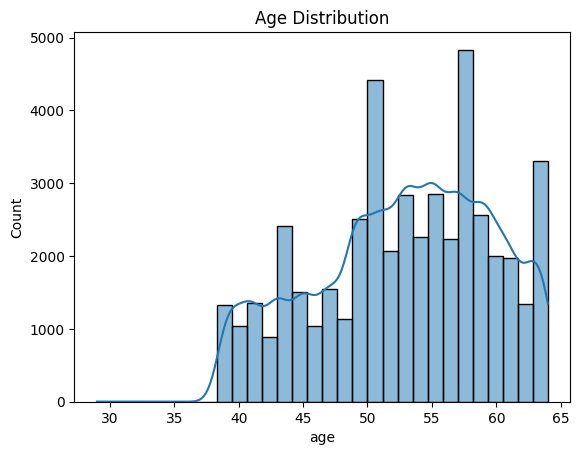

In [140]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

The dataset is primarily composed of individuals aged 40 to 65, representing the middle-aged and senior population. There is a notable absence of younger demographics (below 38 years). The distribution peaks around age 50 and 60, aligning the study with the most clinically relevant age groups for cardiovascular risk assessment.


# The relationship between age and BMI

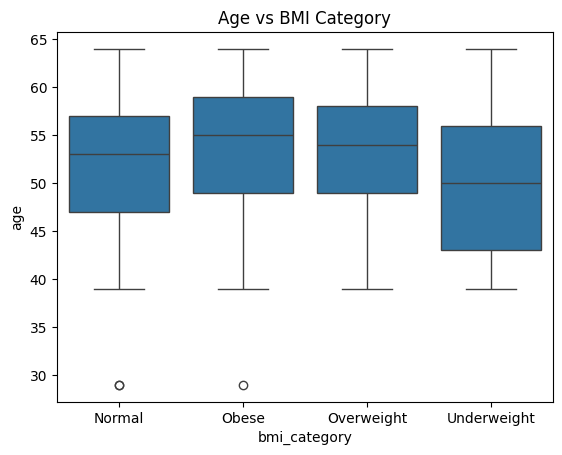

In [141]:
sns.boxplot(x='bmi_category', y='age', data=df)
plt.title("Age vs BMI Category")
plt.show()

The boxplot reveals that BMI categories are relatively consistent across the 40-65 age range. However, a slight trend is observed where the median age for the 'Obese' category is higher than other groups, suggesting that weight gain might be more prevalent as individuals age within this cohort. Most outliers (younger individuals) fall into the 'Normal' weight category.

# Pressure Distribution

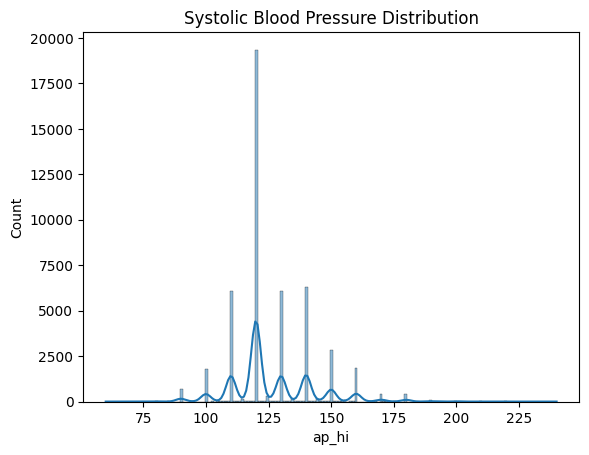

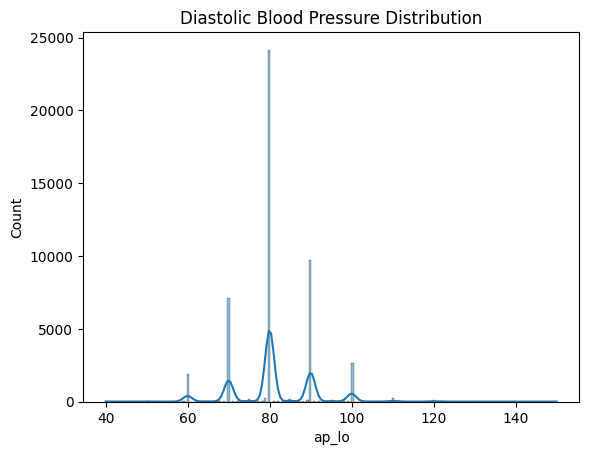

In [142]:
sns.histplot(df['ap_hi'], kde=True)
plt.title("Systolic Blood Pressure Distribution")
plt.show()

sns.histplot(df['ap_lo'], kde=True)
plt.title("Diastolic Blood Pressure Distribution")
plt.show()

Both blood pressure features exhibit a positive (right) skewness, indicating a significant presence of hypertensive individuals in the dataset. While the data peaks at normal clinical levels (120/80), the extended right tail provides the necessary variance for the model to learn high-risk patterns. The values are now within a realistic medical range, confirming successful outlier removal.

# Correlation Heatmap

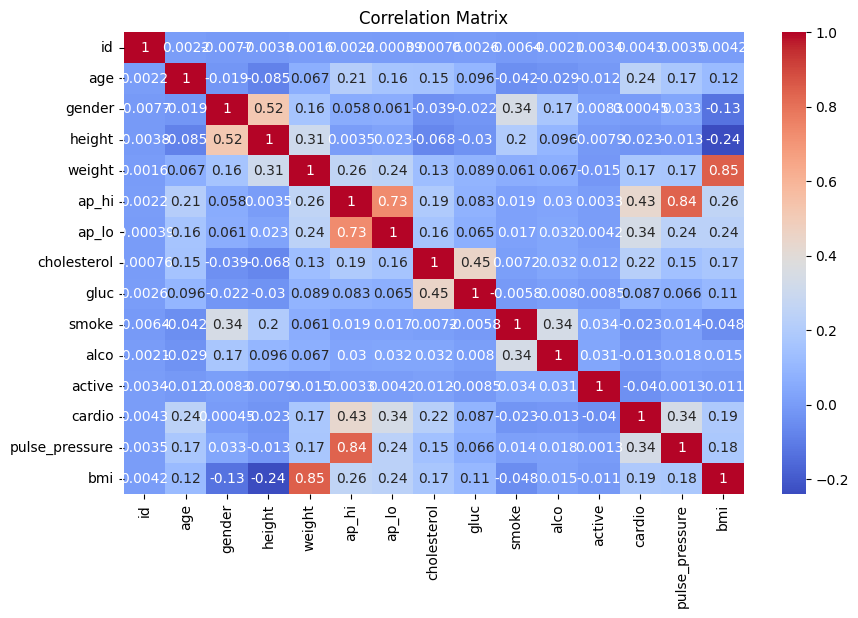

In [143]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

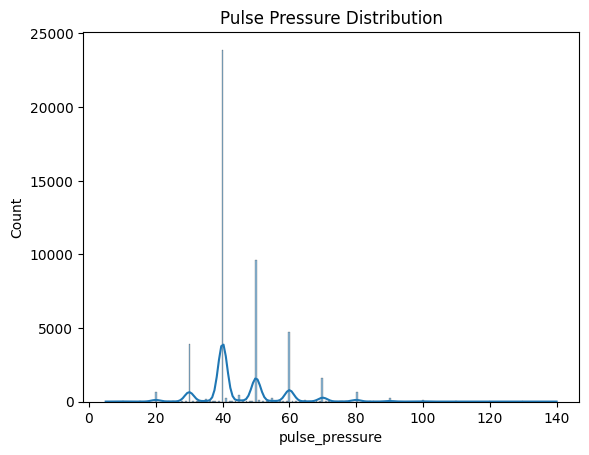

In [144]:
sns.histplot(df['pulse_pressure'], kde=True)
plt.title("Pulse Pressure Distribution")
plt.show()

The distribution peaks exactly at the clinically ideal value of 40 mmHg. However, the presence of values exceeding 60 mmHg represents individuals at higher risk of arterial stiffness and cardiovascular issues. This engineered feature provides a clear physiological marker that will likely enhance the model's predictive accuracy.


# BMI Category vs Pulse Pressure

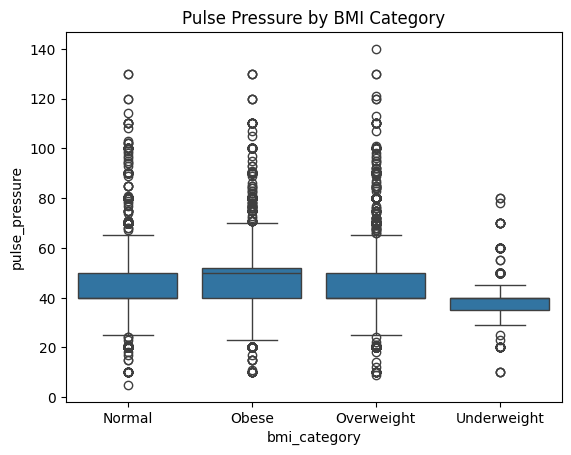

In [145]:
sns.boxplot(x='bmi_category', y='pulse_pressure', data=df)
plt.title("Pulse Pressure by BMI Category")
plt.show()

The boxplot clearly demonstrates that the Obese category maintains the highest median pulse pressure. Additionally, the significant number of high-value outliers in the Obese and Overweight groups suggests that higher body mass is strongly associated with increased arterial strain, reinforcing BMI as a key factor in cardiovascular risk assessment.

/tmp/ipykernel_7018/4111311754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='Set1')


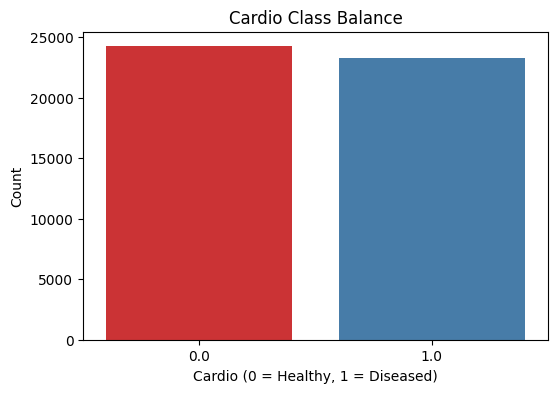

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='cardio', data=df, palette='Set1')
plt.title("Cardio Class Balance")
plt.xlabel("Cardio (0 = Healthy, 1 = Diseased)")
plt.ylabel("Count")
plt.show()

This chart shows the distribution of patients with and without cardiovascular disease. The dataset is balanced, with roughly equal numbers of healthy and diseased individuals, which strengthens our model's reliability.

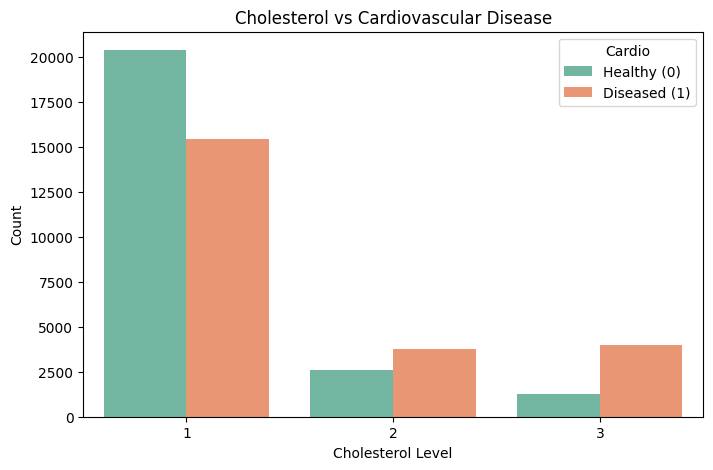

In [147]:
plt.figure(figsize=(8,5))
sns.countplot(x='cholesterol', hue='cardio', data=df, palette='Set2')
plt.title("Cholesterol vs Cardiovascular Disease")
plt.xlabel("Cholesterol Level")
plt.ylabel("Count")
plt.legend(title='Cardio', labels=['Healthy (0)', 'Diseased (1)'])
plt.show()

This chart illustrates the relationship between cholesterol levels and cardiovascular disease. Higher cholesterol levels are associated with an increased risk, confirming its importance as a predictive feature.